# Notebook 11: Hard Contrastive Negative Augmentation

## Purpose
Evaluate the effect of adding hard contrastive negatives to the training set.
Hard contrastive negatives are LLM-generated sentences that superficially
resemble hedging language but do not express genuine epistemic uncertainty —
they are designed to sit near the positive manifold in embedding space without
being true hedges.

Unlike positive augmentation (Notebook 10), contrastive negatives:
- Are added to the **negative class** (label=0)
- Do **not** improve class imbalance — the negative class grows slightly
- Target **decision boundary sharpening** — the classifier sees more
  hard examples near the boundary during training

## Generation
1,342 hard contrastive negatives generated by `Llama-3-8B-Instruct`,
prompted on each real positive training example to produce sentences
with hedging surface markers but without genuine epistemic uncertainty.
6 generation failures from 1,348 attempted (674 seeds × 2).

## Filtering Strategy
Identical to Notebook 10 — cosine similarity to nearest real positive
at τ = 0.5, 0.6, 0.7, 0.8. Here the filter selects candidates that are
geometrically close to the positive manifold, which is exactly what we
want for hard negatives — easy negatives far from the boundary provide
no additional signal.

## Hypothesis
Hard negatives near the positive manifold force the classifier to learn
a more precise decision boundary — improving precision at the cost of
potentially reducing recall. The capacity-augmentation interaction
observed in Notebook 10 (MLP-2 benefits more than MLP-1) may not hold
here since we are sharpening rather than expanding the positive class.

## Imbalance
Adding ~270 hard contrastives (τ=0.8 estimate) to 68,836 real negatives
is negligible in terms of imbalance ratio (~102:1 → ~102.5:1). Any
improvement in metrics reflects boundary geometry, not class rebalancing.

## Evaluation
- UMAP: filtered contrastive negatives overlaid on real training data
- Metrics table: precision, recall, F1 vs Notebook 09 and 10 baselines
- DET curves: all conditions overlaid

In [2]:
# -----------------------------------------------
# Imports and setup — identical to Notebooks 09-10
# -----------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap
os.chdir("..")
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# -----------------------------------------------
# Load real training embeddings and splits
# -----------------------------------------------
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
y_cal   = np.load("data/processed/embeddings/y_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")
y_test  = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# -----------------------------------------------
# Load baseline metrics from Notebooks 09 and 10
# -----------------------------------------------
with open("data/results/metrics_09_baseline.json") as f:
    baseline_09 = json.load(f)

with open("data/results/metrics_10_positive_aug.json") as f:
    baseline_10 = json.load(f)

print("\nNotebook 09 baseline:")
for name, m in baseline_09.items():
    print(f"  {name}: F1={m['f1']:.3f} | P={m['precision']:.3f} | R={m['recall']:.3f}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192

Notebook 09 baseline:
  LR: F1=0.152 | P=0.085 | R=0.729
  MLP-1: F1=0.270 | P=0.190 | R=0.464
  MLP-2: F1=0.207 | P=0.134 | R=0.448


In [3]:
# -----------------------------------------------
# Utilities and model definitions
# Identical to Notebooks 09-10 — self-contained
# -----------------------------------------------
def optimal_threshold_f1(
    y_true, y_scores,
    thresholds=np.arange(0.01, 0.70, 0.01),
):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


class MLP(nn.Module):
    def __init__(self, input_dim=384, hidden_dims=[256], dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class MLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self, hidden_dims=[256], n_epochs=50, lr=1e-3,
        batch_size=256, patience=5, dropout=0.1, random_state=SEED,
    ):
        self.hidden_dims   = hidden_dims
        self.n_epochs      = n_epochs
        self.lr            = lr
        self.batch_size    = batch_size
        self.patience      = patience
        self.dropout       = dropout
        self.random_state  = random_state
        self.classes_      = np.array([0, 1])

    def fit(self, X, y, X_cal=None, y_cal=None):
        torch.manual_seed(self.random_state)
        n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
        class_weights = torch.tensor(
            [1.0 / n_neg, 1.0 / n_pos], dtype=torch.float
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.model_ = MLP(X.shape[1], self.hidden_dims, self.dropout)
        optimizer = AdamW(
            self.model_.parameters(), lr=self.lr, weight_decay=1e-4
        )
        loader = DataLoader(
            TensorDataset(
                torch.tensor(X, dtype=torch.float),
                torch.tensor(y, dtype=torch.long),
            ),
            batch_size=self.batch_size, shuffle=True,
        )
        best_cal_f1, best_weights, no_improve = 0.0, None, 0
        for epoch in range(self.n_epochs):
            self.model_.train()
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch)
                loss.backward()
                optimizer.step()
            if X_cal is not None and y_cal is not None:
                _, cal_f1 = optimal_threshold_f1(
                    y_cal, self.predict_proba(X_cal)[:, 1]
                )
                if cal_f1 > best_cal_f1:
                    best_cal_f1 = cal_f1
                    best_weights = {
                        k: v.clone()
                        for k, v in self.model_.state_dict().items()
                    }
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(best cal F1: {best_cal_f1:.4f})")
                        break
        if best_weights is not None:
            self.model_.load_state_dict(best_weights)
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            probs = torch.softmax(
                self.model_(torch.tensor(X, dtype=torch.float)), dim=1
            ).numpy()
        return probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def evaluate_classifier(clf, X_train, y_train, X_cal, y_cal,
                         X_test, y_test, name="Classifier"):
    if isinstance(clf, MLPClassifier):
        clf.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
    else:
        clf.fit(X_train, y_train)
    cal_scores  = clf.predict_proba(X_cal)[:, 1]
    t, cal_f1   = optimal_threshold_f1(y_cal, cal_scores)
    test_scores = clf.predict_proba(X_test)[:, 1]
    y_pred      = (test_scores >= t).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f"\n=== {name} (threshold={t:.2f}) ===")
    print(classification_report(y_test, y_pred, digits=3))
    return {
        'name': name, 'clf': clf, 'threshold': t,
        'cal_f1': cal_f1, 'test_scores': test_scores,
        'y_pred': y_pred, 'precision': prec, 'recall': rec, 'f1': f1,
    }

print("Utilities and model classes defined.")

Utilities and model classes defined.


In [4]:
# -----------------------------------------------
# Load and encode hard contrastive negatives
# Label=0 throughout — these are hard negatives
# designed to sit near the positive manifold
# -----------------------------------------------
encoder = SentenceTransformer('all-MiniLM-L6-v2')

df_contrastive = pd.read_parquet("data/synthetic/hard_contrastive_raw.parquet")
print(f"Hard contrastive candidates: {len(df_contrastive)}")
print(f"Label distribution: {df_contrastive['label'].value_counts().to_dict()}")

print("\nEncoding contrastive negatives...")
X_contrastive = encoder.encode(
    df_contrastive['sentence'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Contrastive embeddings: {X_contrastive.shape}")

# -----------------------------------------------
# Cosine similarity filter
# Same logic as Notebook 10 — retain candidates
# geometrically close to real positives.
# For hard negatives, high similarity to real
# positives is desirable — these are the boundary
# cases that sharpen the decision surface.
# -----------------------------------------------
X_real_pos = X_train[y_train == 1]  # (674, 384)

sim_matrix   = cosine_similarity(X_contrastive, X_real_pos)
max_sim      = sim_matrix.max(axis=1)

print(f"\nSimilarity distribution:")
print(f"  mean:  {max_sim.mean():.3f}")
print(f"  std:   {max_sim.std():.3f}")
print(f"  min:   {max_sim.min():.3f}")
print(f"  max:   {max_sim.max():.3f}")

for tau in [0.5, 0.6, 0.7, 0.8]:
    mask = max_sim >= tau
    print(f"  τ={tau}: {mask.sum()} survivors ({100*mask.mean():.1f}%)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 319.27it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hard contrastive candidates: 1342
Label distribution: {0: 1342}

Encoding contrastive negatives...


Batches: 100%|██████████| 42/42 [00:06<00:00,  6.77it/s]

Contrastive embeddings: (1342, 384)

Similarity distribution:
  mean:  0.615
  std:   0.104
  min:   0.393
  max:   0.964
  τ=0.5: 1184 survivors (88.2%)
  τ=0.6: 677 survivors (50.4%)
  τ=0.7: 266 survivors (19.8%)
  τ=0.8: 81 survivors (6.0%)


τ=0.7 survivors: 266 / 1342

Augmented training set: (69776, 384)
Positives: 674 | Negatives: 69102 | Ratio: 102.5:1

Fitting UMAP...
Done.


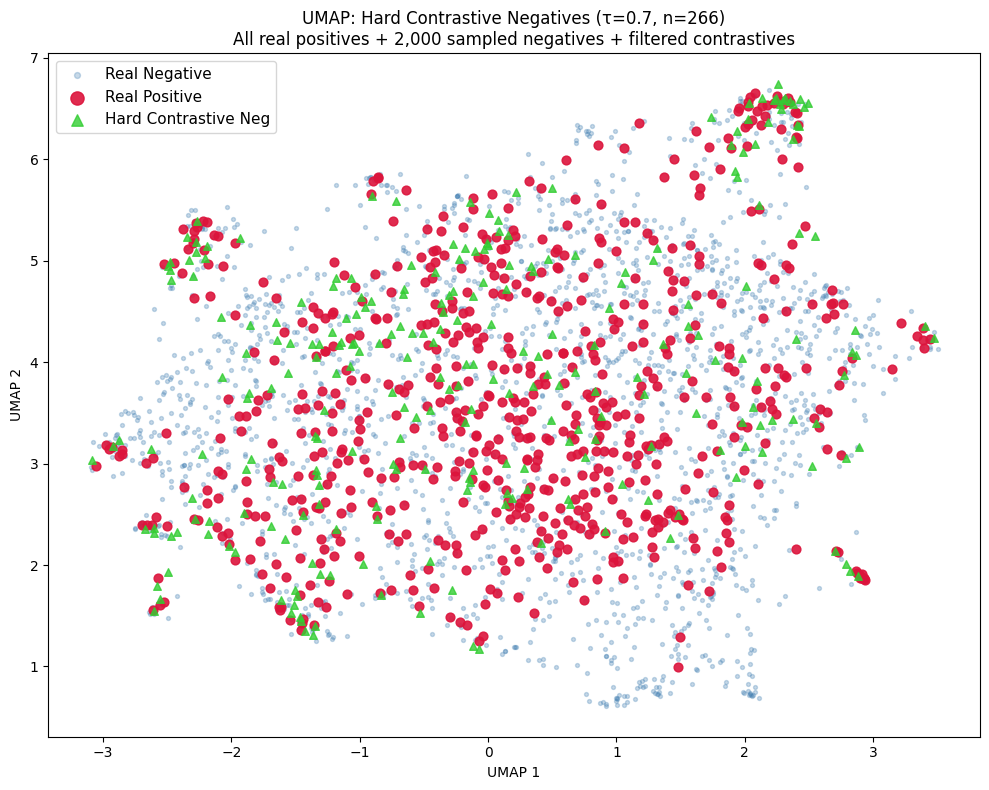

UMAP saved.


In [6]:
# -----------------------------------------------
# Apply τ=0.7 filter and construct augmented
# training set. Hard negatives added to negative
# class — label=0 throughout.
# -----------------------------------------------
TAU = 0.7

contrastive_mask       = max_sim >= TAU
X_contrastive_filtered = X_contrastive[contrastive_mask]
y_contrastive_filtered = np.zeros(contrastive_mask.sum(), dtype=int)

print(f"τ={TAU} survivors: {contrastive_mask.sum()} / {len(contrastive_mask)}")

# Augmented training set
X_train_contrastive = np.vstack([X_train, X_contrastive_filtered])
y_train_contrastive = np.concatenate([y_train, y_contrastive_filtered])

print(f"\nAugmented training set: {X_train_contrastive.shape}")
print(f"Positives: {y_train_contrastive.sum()} | "
      f"Negatives: {(y_train_contrastive==0).sum()} | "
      f"Ratio: {(y_train_contrastive==0).sum()/y_train_contrastive.sum():.1f}:1")

# -----------------------------------------------
# UMAP: hard contrastive negatives overlaid
# on real training data — shows boundary placement
# -----------------------------------------------
np.random.seed(SEED)
pos_idx        = np.where(y_train == 1)[0]
neg_idx        = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

X_plot = np.vstack([
    X_train[pos_idx],
    X_train[neg_sample_idx],
    X_contrastive_filtered,
])
y_plot = (
    ['Real Positive']       * len(pos_idx) +
    ['Real Negative']       * len(neg_sample_idx) +
    ['Hard Contrastive Neg'] * len(X_contrastive_filtered)
)

print("\nFitting UMAP...")
reducer = umap.UMAP(n_components=2, random_state=SEED,
                    n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_plot)
print("Done.")

color_map = {
    'Real Negative':        'steelblue',
    'Real Positive':        'crimson',
    'Hard Contrastive Neg': 'limegreen',
}
size_map = {
    'Real Negative':        8,
    'Real Positive':        40,
    'Hard Contrastive Neg': 30,
}
alpha_map = {
    'Real Negative':        0.3,
    'Real Positive':        0.9,
    'Hard Contrastive Neg': 0.8,
}

fig, ax = plt.subplots(figsize=(10, 8))
for cat in ['Real Negative', 'Real Positive', 'Hard Contrastive Neg']:
    mask = np.array(y_plot) == cat
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=color_map[cat], s=size_map[cat],
        alpha=alpha_map[cat], label=cat,
        marker='^' if cat == 'Hard Contrastive Neg' else 'o'
    )

ax.set_title(
    f'UMAP: Hard Contrastive Negatives (τ={TAU}, n={contrastive_mask.sum()})\n'
    'All real positives + 2,000 sampled negatives + filtered contrastives',
    fontsize=12,
)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig("data/results/umap_contrastive_augmentation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("UMAP saved.")

In [7]:
# -----------------------------------------------
# Train all three classifiers on augmented
# training set — one condition only (contrastive
# negatives added to negative class)
# -----------------------------------------------
results_11 = {}

print("Training LR...")
results_11['LR'] = evaluate_classifier(
    LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    X_train_contrastive, y_train_contrastive,
    X_cal, y_cal, X_test, y_test,
    name="LR (Contrastive)",
)

print("\nTraining MLP-1...")
results_11['MLP-1'] = evaluate_classifier(
    MLPClassifier(hidden_dims=[256], random_state=SEED),
    X_train_contrastive, y_train_contrastive,
    X_cal, y_cal, X_test, y_test,
    name="MLP-1 (Contrastive)",
)

print("\nTraining MLP-2...")
results_11['MLP-2'] = evaluate_classifier(
    MLPClassifier(hidden_dims=[256, 128], random_state=SEED),
    X_train_contrastive, y_train_contrastive,
    X_cal, y_cal, X_test, y_test,
    name="MLP-2 (Contrastive)",
)

Training LR...

=== LR (Contrastive) (threshold=0.69) ===
              precision    recall  f1-score   support

           0      0.997     0.924     0.959     19669
           1      0.086     0.729     0.153       192

    accuracy                          0.922     19861
   macro avg      0.541     0.827     0.556     19861
weighted avg      0.988     0.922     0.951     19861


Training MLP-1...
  Early stopping at epoch 30 (best cal F1: 0.2449)

=== MLP-1 (Contrastive) (threshold=0.69) ===
              precision    recall  f1-score   support

           0      0.994     0.984     0.989     19669
           1      0.205     0.417     0.275       192

    accuracy                          0.979     19861
   macro avg      0.600     0.700     0.632     19861
weighted avg      0.987     0.979     0.982     19861


Training MLP-2...
  Early stopping at epoch 15 (best cal F1: 0.2180)

=== MLP-2 (Contrastive) (threshold=0.51) ===
              precision    recall  f1-score   support

 

Condition                 Classifier    Precision   Recall       F1
---------------------------------------------------------------------------
Baseline                  LR                0.085    0.729    0.152
Baseline                  MLP-1             0.190    0.464    0.270
Baseline                  MLP-2             0.134    0.448    0.207
Vanilla aug               LR                0.089    0.693    0.158
Vanilla aug               MLP-1             0.132    0.521    0.211
Vanilla aug               MLP-2             0.183    0.354    0.242
CoT aug                   LR                0.087    0.708    0.155
CoT aug                   MLP-1             0.171    0.521    0.257
CoT aug                   MLP-2             0.168    0.432    0.242
Contrastive aug           LR                0.086    0.729    0.153
Contrastive aug           MLP-1             0.205    0.417    0.275
Contrastive aug           MLP-2             0.140    0.505    0.219


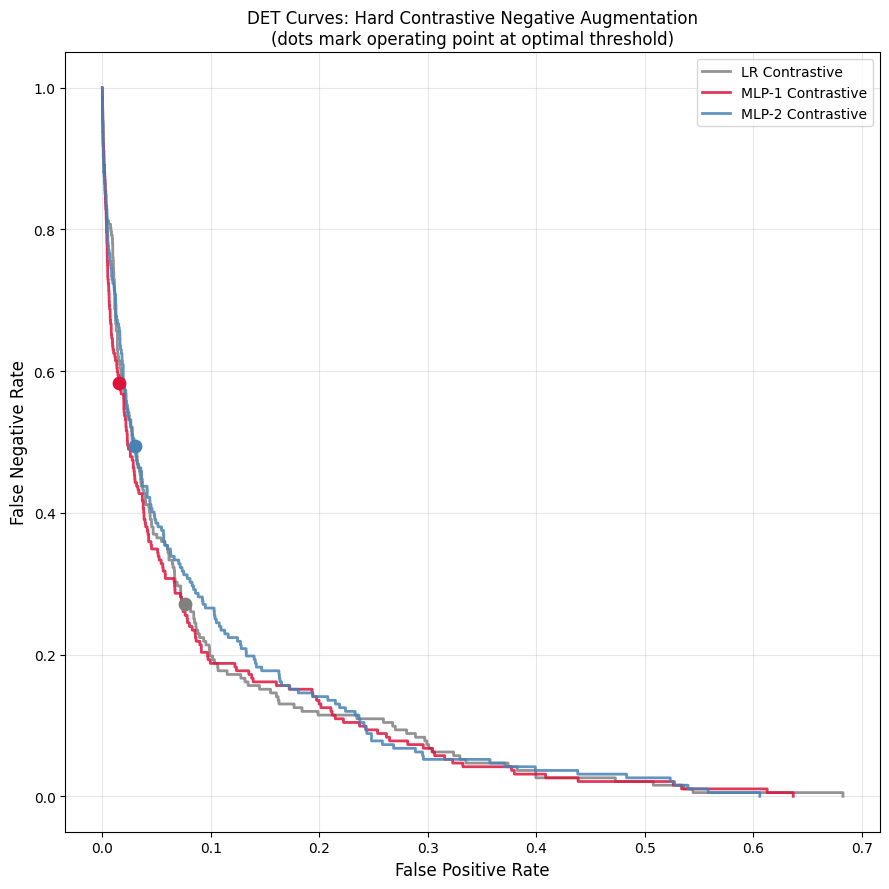

DET curves saved.
Metrics saved to data/results/metrics_11_contrastive_aug.json


In [8]:
# -----------------------------------------------
# Summary table — all notebooks
# -----------------------------------------------
print("=" * 75)
print(f"{'Condition':<25} {'Classifier':<12} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8}")
print("-" * 75)

# Notebook 09 baseline
for clf_name, m in baseline_09.items():
    print(f"{'Baseline':<25} {clf_name:<12} {m['precision']:>10.3f} "
          f"{m['recall']:>8.3f} {m['f1']:>8.3f}")

# Notebook 10
for cond_name, cond_results in baseline_10.items():
    for clf_name, m in cond_results.items():
        print(f"{cond_name+' aug':<25} {clf_name:<12} {m['precision']:>10.3f} "
              f"{m['recall']:>8.3f} {m['f1']:>8.3f}")

# Notebook 11
for clf_name, r in results_11.items():
    print(f"{'Contrastive aug':<25} {clf_name:<12} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['f1']:>8.3f}")
print("=" * 75)

# -----------------------------------------------
# DET curves
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

clf_colors  = {'LR': 'gray', 'MLP-1': 'crimson', 'MLP-2': 'steelblue'}
cond_styles = {'Contrastive': '-'}

for clf_name, r in results_11.items():
    fpr, fnr, _ = det_curve(y_test, r['test_scores'])
    ax.plot(
        fpr, fnr,
        color=clf_colors[clf_name],
        linestyle='-',
        linewidth=2,
        label=f"{clf_name} Contrastive",
        alpha=0.85,
    )
    # Mark operating point
    fp = ((r['y_pred']==1) & (y_test==0)).sum() / (y_test==0).sum()
    fn = ((r['y_pred']==0) & (y_test==1)).sum() / (y_test==1).sum()
    ax.scatter(fp, fn, color=clf_colors[clf_name], s=80, zorder=5)

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("False Negative Rate", fontsize=12)
ax.set_title(
    "DET Curves: Hard Contrastive Negative Augmentation\n"
    "(dots mark operating point at optimal threshold)",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/results/det_curves_11.png", dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

# -----------------------------------------------
# Save metrics
# -----------------------------------------------
import json

metrics_11 = {
    clf_name: {
        'precision': round(r['precision'], 4),
        'recall':    round(r['recall'], 4),
        'f1':        round(r['f1'], 4),
        'threshold': round(r['threshold'], 4),
        'cal_f1':    round(r['cal_f1'], 4),
    }
    for clf_name, r in results_11.items()
}

with open("data/results/metrics_11_contrastive_aug.json", "w") as f:
    json.dump(metrics_11, f, indent=2)
print("Metrics saved to data/results/metrics_11_contrastive_aug.json")